In [ ]:
import torch
import torchvision

trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=None)

In [ ]:
transform_mean = trainset.data.numpy().mean()/255.0
transform_std = trainset.data.numpy().std()/255.0

In [ ]:
transform = torchvision.transforms.Compose(
    (
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            transform_mean,
            transform_std
          )
     )
)
trainset.transform = transform
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=2048,
    shuffle=True
)
testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
testloader = torch.utils.data.DataLoader(testset, batch_size = 1, shuffle=False)

class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = torch.nn.ReLU()
        self.flatten = torch.nn.Flatten()
        self.linear1 = torch.nn.Linear(784, 1024)
        self.linear2 = torch.nn.Linear(1024, 2048)
        self.linear3 = torch.nn.Linear(2048, 256)
        self.linear4 = torch.nn.Linear(256, 10)
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):       # 2048, 1, 28, 28
        x = self.flatten(x)     # 2048, 784
        x = self.linear1(x)     # 2048, 1024
        x = self.relu(x)
        x = self.linear2(x)     # 2048, 2048
        x = self.relu(x)
        x = self.linear3(x)     # 2048, 256
        x = self.relu(x)
        x = self.dropout(x)
        x = self.linear4(x)     # 2048, 10
        return x

In [ ]:
from torch.utils import data
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(f'Working on {device}')

net = MLP().to(device)
optimizer = torch.optim.Adam(net.parameters(), .001)
cross_entropy = torch.nn.functional.cross_entropy
n_epochs = 8
net.train()

for _ in range(n_epochs):
  for data in trainloader:
    batch_inputs, batch_labels = data
    batch_inputs = batch_inputs.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()
    batch_outputs = net(batch_inputs) # call to forward(self, x)
    loss = cross_entropy(batch_outputs, batch_labels, reduction = 'mean')
    loss.backward()
    optimizer.step()




Working on cuda


In [ ]:
good = 0
wrong = 0

net.eval()
with torch.no_grad():
  for data in testloader:
    datapoint, label = data
    datapoint = datapoint.to(device)
    label = label.to(device)

    prediction = net(datapoint)
    classification = torch.argmax(prediction)
    if classification.item() == label.item():
      good += 1
    else:
      wrong += 1
print("accuracy = ", good/(good+wrong))

accuracy =  0.9798


##Task 1: Random Gaussian noise images

In [ ]:
net.eval()
random_noise = torch.randn(size=(10, 1, 28, 28))
targets = torch.arange(10, dtype=torch.long)

random_noise = random_noise.to(device)
random_noise.requires_grad = True
targets = targets.to(device)

optimizer = torch.optim.Adam((random_noise,), lr=.05)
n_iter = 25
for _ in range(n_iter):
  optimizer.zero_grad()
  noise_outputs = net(random_noise)
  loss = cross_entropy(noise_outputs, targets, reduction='mean')
  loss.backward()
  optimizer.step()

print(loss.item())

7.620911492267624e-05


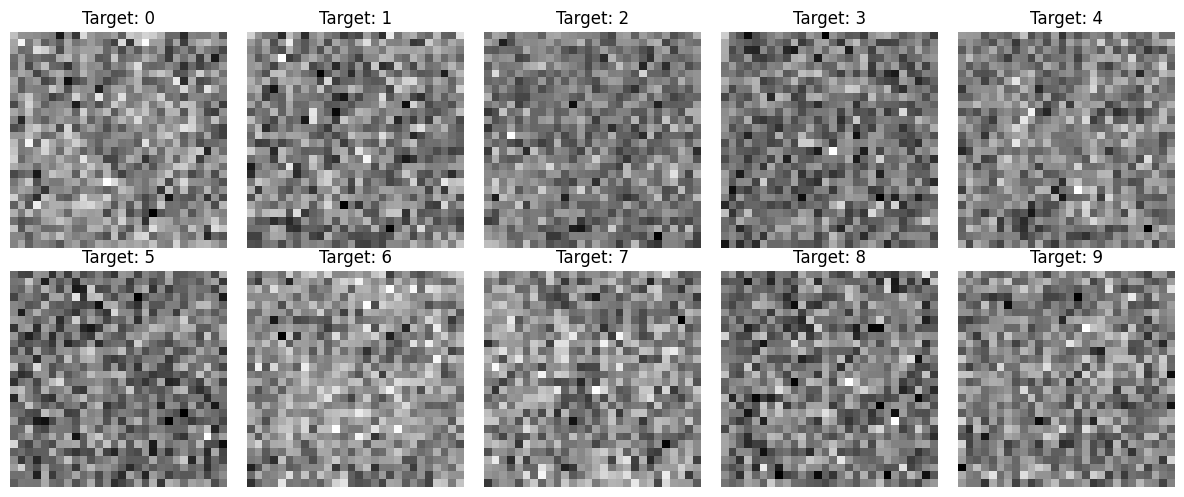

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
  img = random_noise[i].detach().cpu().squeeze().numpy()
  ax.imshow(img, cmap='gray')
  ax.set_title(f"Target: {i}")
  ax.axis('off')
plt.tight_layout()
plt.show()

The generated images do not resemble real MNIST digits and mostly look like random noise. The optimization minimizes the cross-entropy loss
\begin{equation}
\ell(x,y)=\sum_{n=1}^{10}-\log\left(
\frac{\exp(x_{n,y_n})}{\sum_{i=1}^{10}\exp(x_{n,i})}
\right),
\end{equation}
which only forces the network to assign high probability to the target class.

The classifier has learned decision boundaries, not the true distribution of handwritten digits. Therefore, gradient descent finds pixel patterns that maximize class scores in $\mathbb R^{784}$, rather than producing realistic digit shapes. These are adversarially optimized inputs rather than genuine MNIST samples.

## Task 2: Dreaming Two Digits Simultaneously


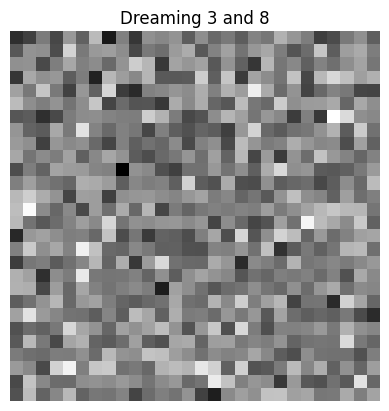

In [ ]:
multi_noise = torch.randn(1, 1, 28, 28)
optimizer = torch.optim.Adam((multi_noise,), lr=0.05)
multi_noise = multi_noise.to(device)
multi_noise.requires_grad = True

target_class_A = 3
target_class_B = 8
n_iter = 200

soft_target = torch.zeros(1, 10)
soft_target = soft_target.to(device)
soft_target[0, target_class_A] = 0.5
soft_target[0, target_class_B] = 0.5

for _ in range(n_iter):
  optimizer.zero_grad()
  logits = net(multi_noise)
  log_probs = torch.log_softmax(logits, dim=1)

  loss = -(soft_target * log_probs).sum()
  loss.backward()
  optimizer.step()

plt.imshow(multi_noise.detach().cpu().squeeze(), cmap='gray')
plt.title(f"Dreaming {target_class_A} and {target_class_B}")
plt.axis("off")
plt.show()

The objective was to minimize the cross-entropy between this soft target and the network's predictions. The loss function is defined as:

\begin{equation}
  \ell(x, y) = - \frac{1}{2}\left(\log\left(\frac{\exp(z_3)}{\sum_{i = 0}^9\exp(z_i)}\right) + \log\left(\frac{\exp(z_8)}{\sum_{i = 0}^9\exp(z_i)} \right)\right).
\end{equation}

This formulation reaches its theoretical minimum when the network assigns equal, maximized log-probabilities to both classes $z_3 = z_8$. By treating the input pixels as trainable parameters, the optimizer adjusts the noise until the model is convinced it sees both digits with equal confidence.

## Task 3: Adding L2 penalty

In [165]:
lambdas = (.001, .01, .1, 1.0, 10.0)
results = {}
n_iter = 200

for l2_lambda in lambdas:
  reg_noise = torch.randn(10, 1, 28, 28)
  reg_noise = reg_noise.to(device)
  reg_noise.requires_grad = True
  optimizer = torch.optim.Adam((reg_noise,), lr=0.05)

  for _ in range(n_iter):
    optimizer.zero_grad()
    outputs = net(reg_noise)

    ce_loss = torch.nn.functional.cross_entropy(outputs, targets)
    l2_loss = l2_lambda * reg_noise.pow(2).mean()
    total_loss = ce_loss + l2_loss

    total_loss.backward()
    optimizer.step()

  results[l2_lambda] = reg_noise.detach().cpu()
  print(f"lambda={l2_lambda}, final loss={total_loss.item():.6f}")

lambda=0.001, final loss=0.001193
lambda=0.01, final loss=0.010386
lambda=0.1, final loss=0.056850
lambda=1.0, final loss=0.057775
lambda=10.0, final loss=0.094266


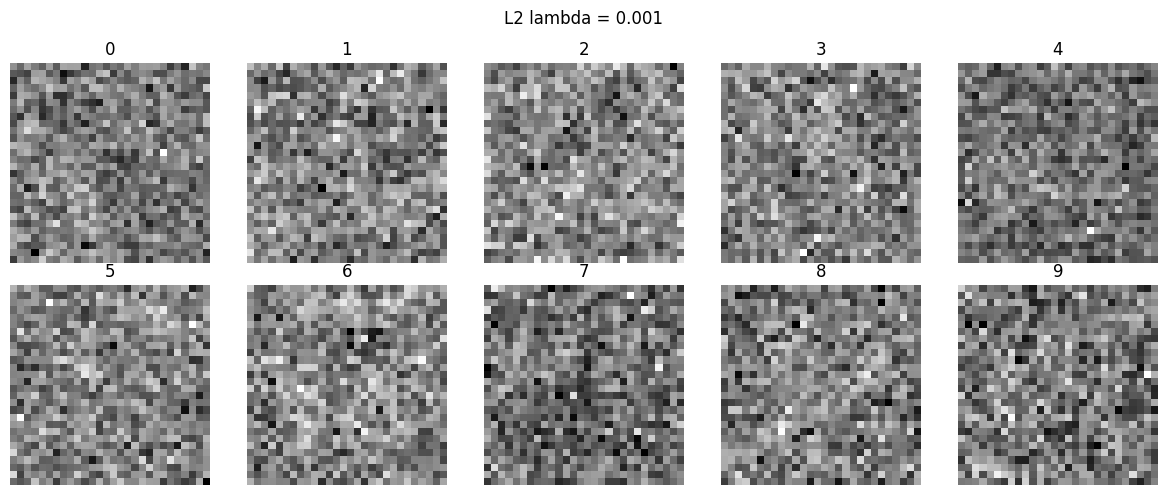

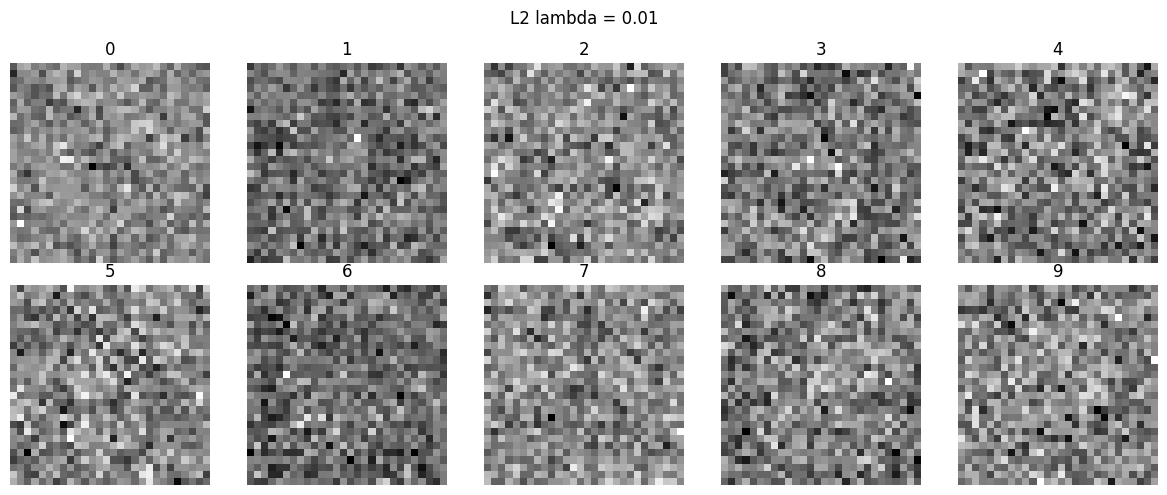

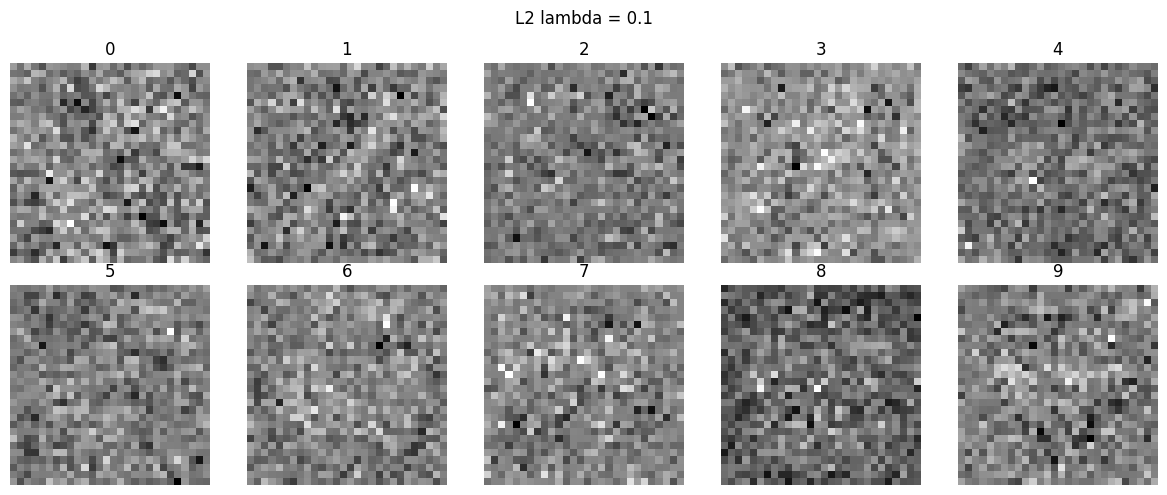

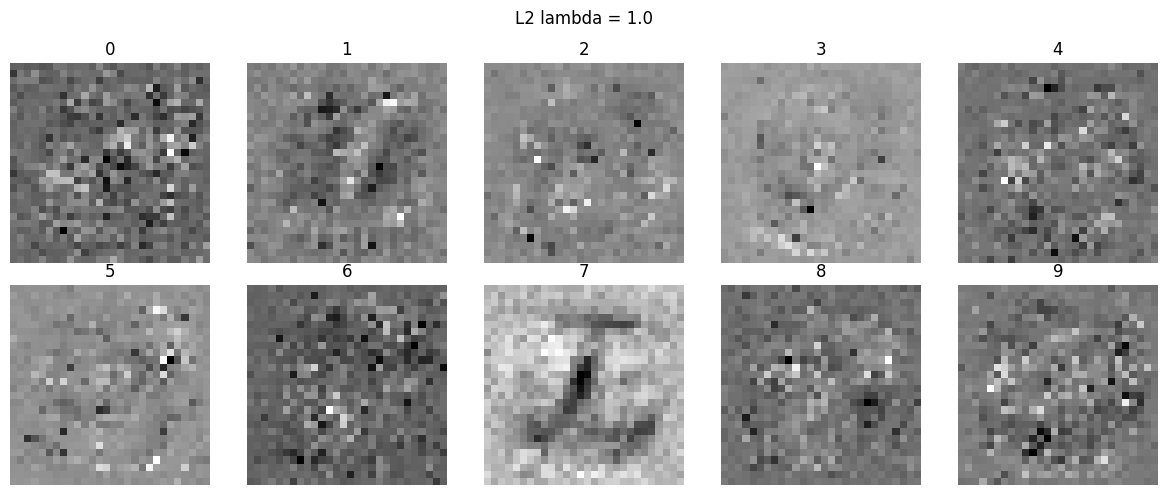

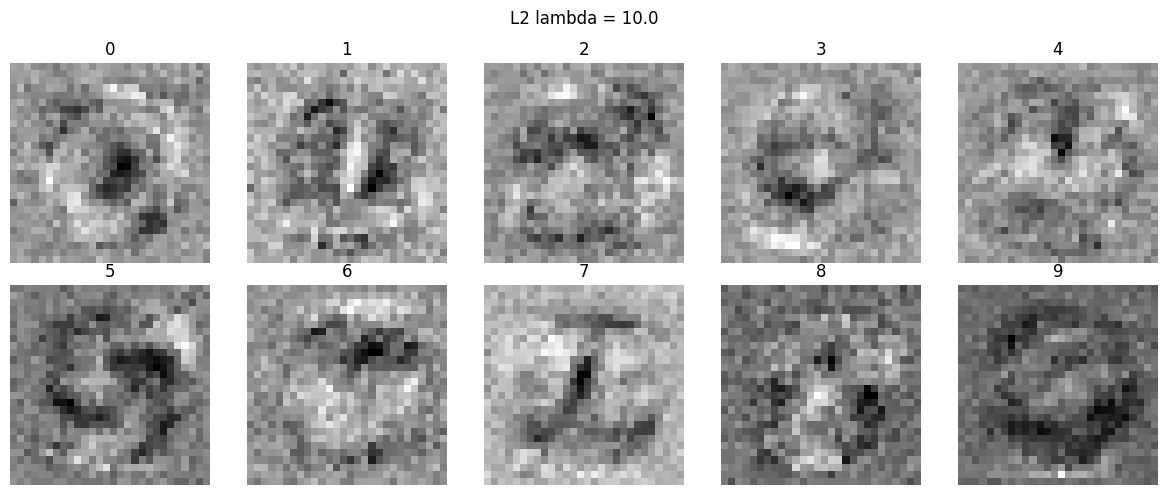

In [166]:
for l2_lambda, imgs in results.items():
  fig, axes = plt.subplots(2, 5, figsize=(12, 5))
  fig.suptitle(f"L2 lambda = {l2_lambda}")

  for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(f"{i}")
    ax.axis('off')

  plt.tight_layout()
  plt.show()

Adding L2 penalty, defined mathematically as proportional to $\sum_i x_i^2$, affects the optimization landscape


*   Without strong regularization, the optimizer minimizes the classification loss by exploiting non-robust features. It does this by driving a few specific pixels to extreme values, creating high-frequency noise, that perfectly align with the network's weights to trigger a confident prediction.
*   The L2 penalty heavily penalizes large individual pixel values quadratically. To achieve a low cross-entropy loss while keeping the L2 penalty low, the optimizer can no longer rely on a few extreme pixel spikes.
*   Forced to keep pixel intensities small and distributed, the optimizer must excite the pixels that are most "efficient" at triggering the target class. These efficient pixels naturally correspond to the robust, low-frequency spatial patterns the network learned during training—the actual structural shapes of the handwritten digits.

The L2 penalty forces the network to dream using the broad strokes it learned, rather than relying on imperceptible, noisy tricks.
